**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 6**
Ingeniería de características (FE)

---

*   NOMBRE: Alejandro Benjamin Rodriguez Mares
*   MATRÍCULA: A01840836


En esta actividad trabajarás con el archivo `computer_prices.csv`, basado en un conjunto de datos sobre características técnicas y especificaciones de computadoras portátiles y de escritorio, disponible en Kaggle.

Los datos fueron recopilados para analizar el rendimiento y el precio de los dispositivos, e incluyen información sobre hardware, almacenamiento, conectividad y otras especificaciones técnicas. Los indicadores incluidos son:

* `device_type`: Tipo de dispositivo (ej. laptop, desktop)
* `brand`: Marca del dispositivo
* `model`: Modelo del dispositivo
* `release_year`: Año de lanzamiento del dispositivo
* `os`: Sistema operativo instalado
* `form_factor`: Factor de forma o diseño del dispositivo (ej. laptop, ultrabook, desktop tower)
* `cpu_brand`: Marca del procesador
* `cpu_tier`: Nivel o gama del procesador, ordinal del 1 al 6 según desempeño
* `cpu_cores`: Número de núcleos del procesador
* `cpu_threads`: Número de hilos de ejecución del procesador
* `gpu_brand`: Marca de la tarjeta gráfica
* `gpu_model`: Modelo específico de la tarjeta gráfica
* `gpu_tier`: Nivel o gama de la GPU, ordinal del 1 al 6 según desempeño
* `vram_gb`: Memoria de video de la GPU en gigabytes
* `ram_gb`: Memoria RAM del dispositivo en gigabytes
* `storage_type`: Tipo de almacenamiento (ej. HDD, SSD)
* `storage_gb`: Capacidad de almacenamiento en gigabytes
* `storage_drive_count`: Número de unidades de almacenamiento instaladas
* `display_type`: Tipo de pantalla (ej. IPS, TN, OLED)
* `charger_watts`: Potencia del cargador (en watts) para laptops
* `psu_watts`: Potencia de la fuente de poder (en watts) para desktops
* `wifi`: Estándar de conectividad Wi-Fi (ej. Wi-Fi 5, 6, 6E, 7)
* `bluetooth`: Versión de Bluetooth
* `weight_kg`: Peso del dispositivo en kilogramos
* `warranty_months`: Meses de garantía del dispositivo
* `price`: Precio del dispositivo. Es la variable de salida o *target*, es decir, la que se pretende predecir más adelante al construir el modelo.

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.

In [1]:
# Instalar las bibliotecas necesarias
!pip install category_encoders -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.2 MB/s eta 0:00:00


In [2]:
# Importar las bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date
from scipy.stats import probplot
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.preprocessing import FunctionTransformer, PowerTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from category_encoders.binary import BinaryEncoder


1. Descarga el archivo: `computer_prices.csv` y guarda, en un dataframe (`compu_df`), todos sus registros.
* Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas de texto?
* Determina la cantidad de valores únicos por columna.
* Elimina las variables:
  * `model`: Debido a su altísima cardinalidad, lo que dificulta su uso en análisis y modelado.
  * `cpu_model`: Además de su elevada cardinalidad, su información ya está representada de manera implícita en otras variables como: `cpu_tier`, `cpu_cores` y `cpu_threads`

In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
import os
DIR = "/content/drive/MyDrive/Colab Notebooks/MNA/TC5053 - Ciencia y analítica de datos/Semana 6"
os.chdir(DIR)


In [5]:
compu_df = pd.read_csv('computer_prices.csv')
compu_df.head()


,device_type,brand,model,release_year,os,form_factor,cpu_brand,cpu_model,cpu_tier,cpu_cores,...,storage_gb,storage_drive_count,display_type,charger_watts,psu_watts,wifi,bluetooth,weight_kg,warranty_months,price
0,Desktop,Samsung,Samsung Forge XDI,2022,Windows,ATX,Intel,Intel i5-11129,3,12,...,1024,1,LED,0,750,Wi-Fi 6,5.1,11.00,36,1383.99
1,Laptop,Samsung,Samsung Pro KM8,2022,Windows,Mainstream,Intel,Intel i7-11114,4,12,...,512,1,OLED,120,0,Wi-Fi 6,5.3,2.03,12,2274.99
2,Desktop,Lenovo,Lenovo Strix BIE,2024,macOS,SFF,AMD,AMD Ryzen 5 5168,2,8,...,512,2,LED,0,850,Wi-Fi 6,5.0,7.00,24,1879.99
3,Desktop,Dell,Dell Cube AXR,2024,Windows,ATX,AMD,AMD Ryzen 5 7550,2,6,...,512,2,IPS,0,650,Wi-Fi 6,5.2,6.00,36,1331.99
4,Laptop,Gigabyte,Gigabyte Pro IX1,2024,Linux,Gaming,AMD,AMD Ryzen 7 6230,5,16,...,256,1,Mini-LED,90,0,Wi-Fi 6,5.2,1.50,12,2681.99


In [6]:
compu_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 27 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   device_type          100000 non-null  object 
 1   brand                100000 non-null  object 
 2   model                100000 non-null  object 
 3   release_year         100000 non-null  int64  
 4   os                   100000 non-null  object 
 5   form_factor          100000 non-null  object 
 6   cpu_brand            100000 non-null  object 
 7   cpu_model            100000 non-null  object 
 8   cpu_tier             100000 non-null  int64  
 9   cpu_cores            100000 non-null  int64  
 10  cpu_threads          100000 non-null  int64  
 11  gpu_brand            100000 non-null  object 
 12  gpu_model            100000 non-null  object 
 13  gpu_tier             100000 non-null  int64  
 14  vram_gb              100000 non-null  int64  
 15  ram_gb            

In [7]:
compu_df.nunique().sort_values()


,0
device_type,2
cpu_brand,3
os,4
gpu_brand,4
warranty_months,4
wifi,4
storage_drive_count,4
storage_type,4
storage_gb,5
bluetooth,5


In [8]:
compu_df = compu_df.drop(columns=['model', 'cpu_model'])
compu_df.head()


,device_type,brand,release_year,os,form_factor,cpu_brand,cpu_tier,cpu_cores,cpu_threads,gpu_brand,...,storage_gb,storage_drive_count,display_type,charger_watts,psu_watts,wifi,bluetooth,weight_kg,warranty_months,price
0,Desktop,Samsung,2022,Windows,ATX,Intel,3,12,24,NVIDIA,...,1024,1,LED,0,750,Wi-Fi 6,5.1,11.00,36,1383.99
1,Laptop,Samsung,2022,Windows,Mainstream,Intel,4,12,24,NVIDIA,...,512,1,OLED,120,0,Wi-Fi 6,5.3,2.03,12,2274.99
2,Desktop,Lenovo,2024,macOS,SFF,AMD,2,8,16,NVIDIA,...,512,2,LED,0,850,Wi-Fi 6,5.0,7.00,24,1879.99
3,Desktop,Dell,2024,Windows,ATX,AMD,2,6,12,AMD,...,512,2,IPS,0,650,Wi-Fi 6,5.2,6.00,36,1331.99
4,Laptop,Gigabyte,2024,Linux,Gaming,AMD,5,16,32,NVIDIA,...,256,1,Mini-LED,90,0,Wi-Fi 6,5.2,1.50,12,2681.99


Al inicio hay 15 columnas numericas y 12 de texto. Quite model y cpu_model porque tienen demasiados valores diferentes y seria dificil usarlas asi. Ademas cpu_model se parece a informacion que ya esta en cpu_tier, cpu_cores y cpu_threads.


2. Antes de iniciar con el análisis univariado, verifica si hay valores duplicados y/o faltantes.
* Obtén las estadísticas descriptivas, separado las numéricas y las categóricas. De estas últimas incluye las tablas de frecuencia.
* Genera histogramas para las numéricas y diagramas de barras para las categóricas. Con alta cardinalidad, sólo incluye los 10 valores más frecuentes.

In [9]:
print('Duplicados:', compu_df.duplicated().sum())
print('Faltantes:', compu_df.isna().sum().sum())


Duplicados: 0
Faltantes: 0


In [10]:
num_cols = compu_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = compu_df.select_dtypes(include='object').columns.tolist()

compu_df[num_cols].describe()


,release_year,cpu_tier,cpu_cores,cpu_threads,gpu_tier,vram_gb,ram_gb,storage_gb,storage_drive_count,charger_watts,psu_watts,bluetooth,weight_kg,warranty_months,price
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000
mean,2022.320850,3.153490,10.515740,19.372700,2.991350,6.152180,39.706400,903.936000,1.524980,61.383450,272.520500,5.084764,4.289699,22.20036,1928.764220
std,2.025761,1.373175,5.044092,9.718426,1.459643,3.964926,31.902684,774.243654,0.797284,62.795034,354.686355,0.245977,3.814628,10.23190,580.492689
min,2018.000000,1.000000,4.000000,4.000000,1.000000,0.000000,8.000000,256.000000,1.000000,0.000000,0.000000,4.200000,0.920000,12.00000,372.990000
25%,2021.000000,2.000000,6.000000,12.000000,2.000000,4.000000,16.000000,512.000000,1.000000,0.000000,0.000000,5.000000,1.500000,12.00000,1503.990000
50%,2023.000000,3.000000,8.000000,16.000000,3.000000,6.000000,32.000000,512.000000,1.000000,65.000000,0.000000,5.100000,2.000000,24.00000,1863.990000
75%,2024.000000,4.000000,14.000000,24.000000,4.000000,8.000000,64.000000,1024.000000,2.000000,90.000000,650.000000,5.200000,7.000000,24.00000,2287.990000
max,2025.000000,6.000000,28.000000,56.000000,6.000000,16.000000,144.000000,4096.000000,4.000000,240.000000,1200.000000,5.300000,16.000000,48.00000,10984.990000


In [11]:
compu_df[cat_cols].describe()


,device_type,brand,os,form_factor,cpu_brand,gpu_brand,gpu_model,storage_type,display_type,wifi
count,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000
unique,2,10,4,10,3,4,49,4,6,4
top,Laptop,Lenovo,Windows,Mainstream,Intel,NVIDIA,Apple Integrated,NVMe,LED,Wi-Fi 6
freq,59844,15992,71817,17819,52774,54712,18922,45059,32000,46149


In [12]:
for col in cat_cols:
    print(col)
    print(compu_df[col].value_counts().head(10))
    print()


device_type
device_type
Laptop     59844
Desktop    40156
Name: count, dtype: int64

brand
brand
Lenovo      15992
HP          14114
Dell        14005
Apple       11915
ASUS        10159
Acer         9925
Samsung      8066
MSI          7891
Gigabyte     4900
Razer        3033
Name: count, dtype: int64

os
os
Windows     71817
macOS       18207
Linux        6109
ChromeOS     3867
Name: count, dtype: int64

form_factor
form_factor
Mainstream     17819
Gaming         16876
ATX            15597
Ultrabook      13236
Micro-ATX       8672
Full-Tower      7110
2-in-1          7049
SFF             5585
Workstation     4864
Mini-ITX        3192
Name: count, dtype: int64

cpu_brand
cpu_brand
Intel    52774
AMD      35311
Apple    11915
Name: count, dtype: int64

gpu_brand
gpu_brand
NVIDIA    54712
Apple     18922
AMD       15767
Intel     10599
Name: count, dtype: int64

gpu_model
gpu_model
Apple Integrated    18922
RTX 40 70            5743
RTX 30 70            5692
RTX 40 60            5437
RTX

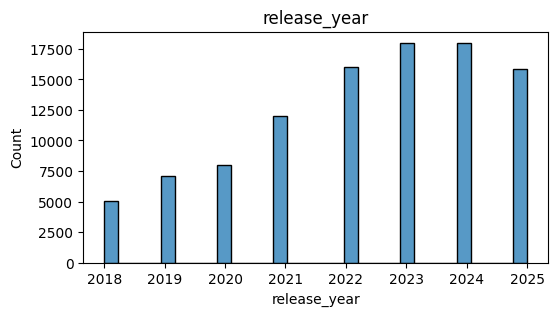

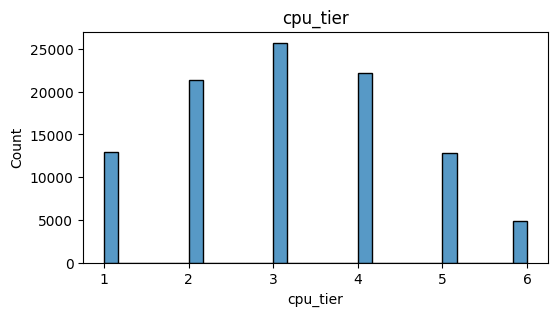

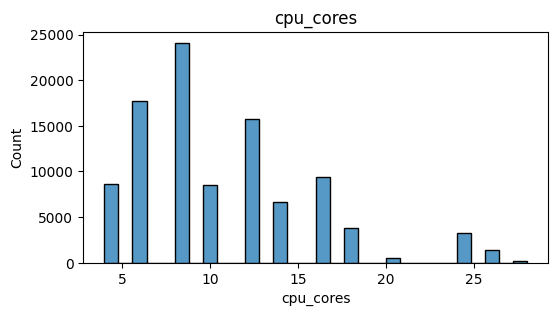

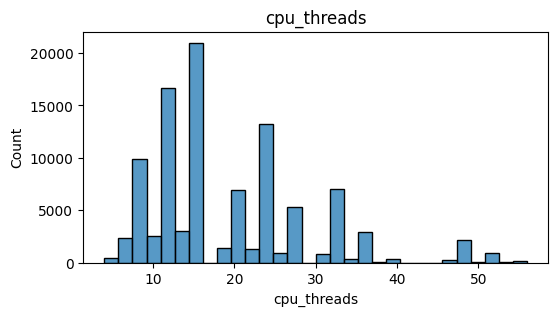

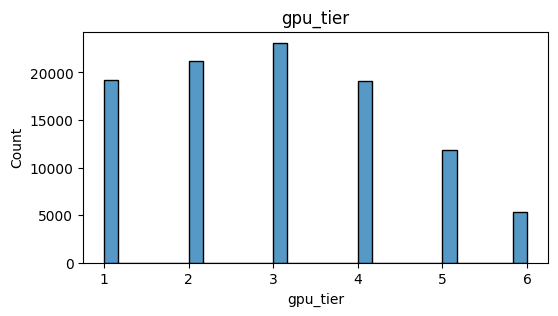

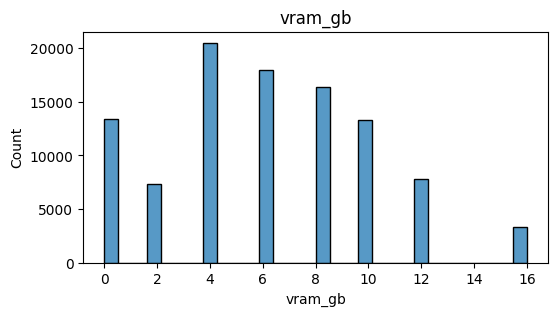

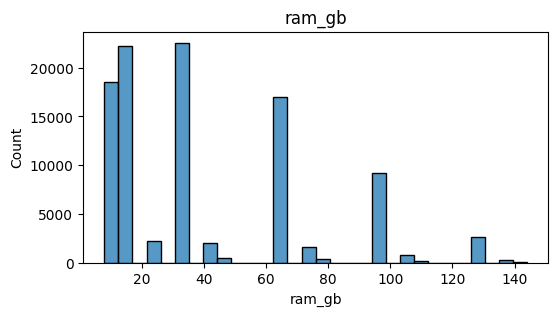

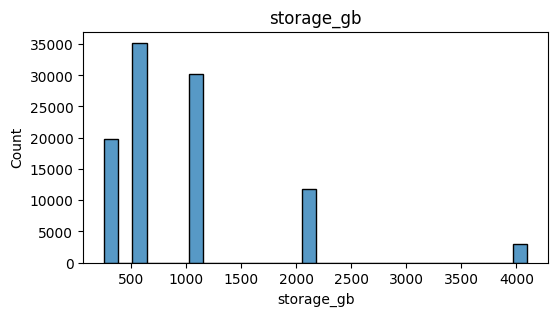

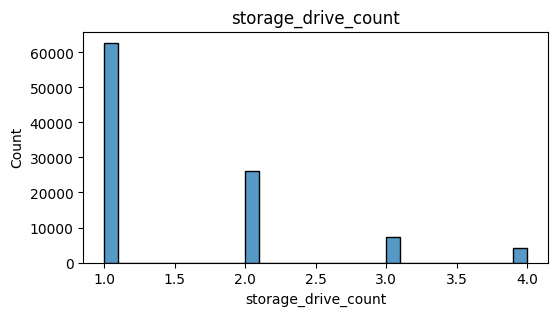

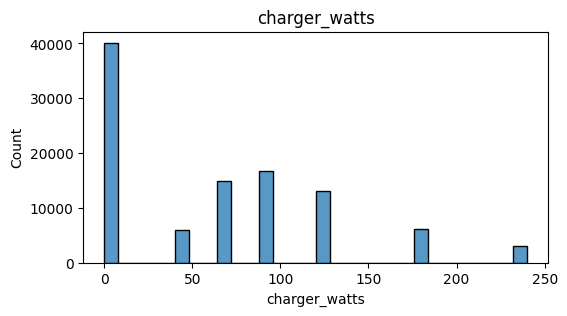

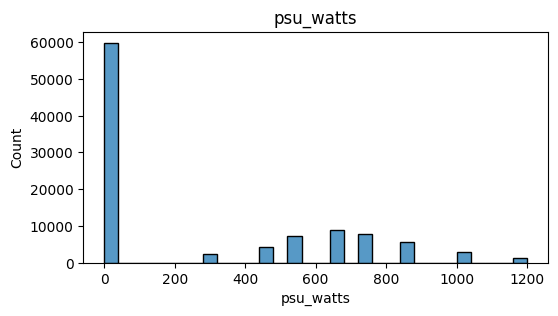

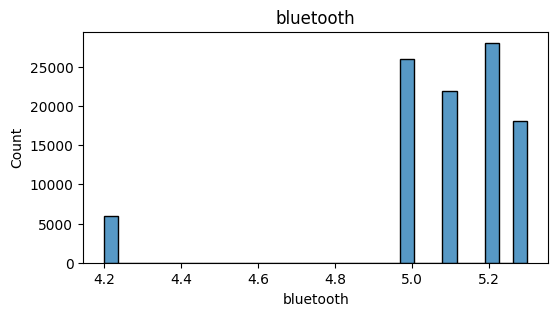

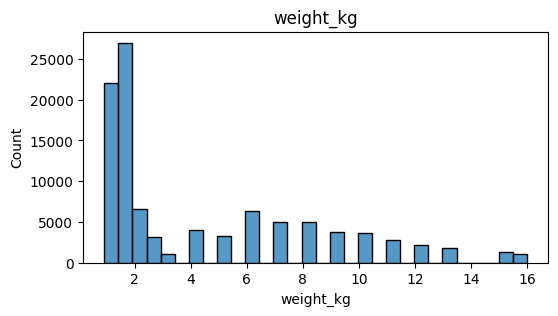

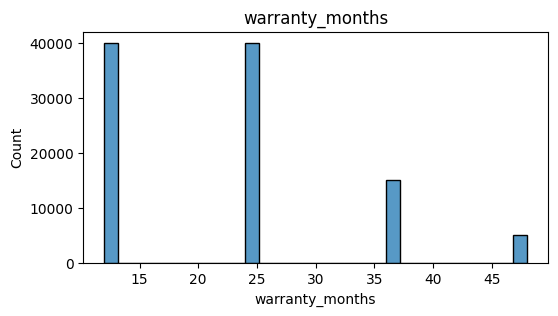

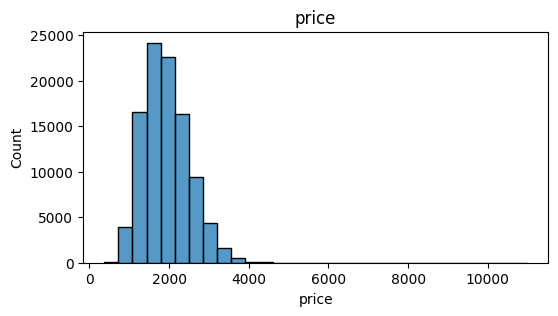

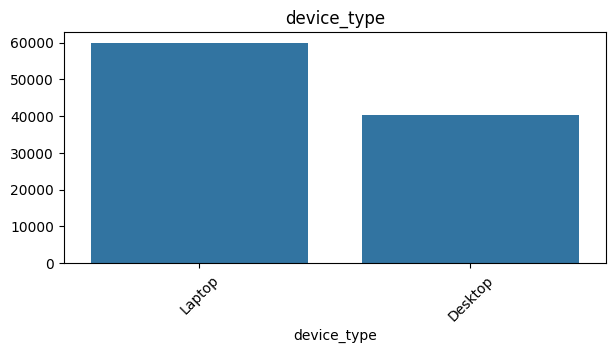

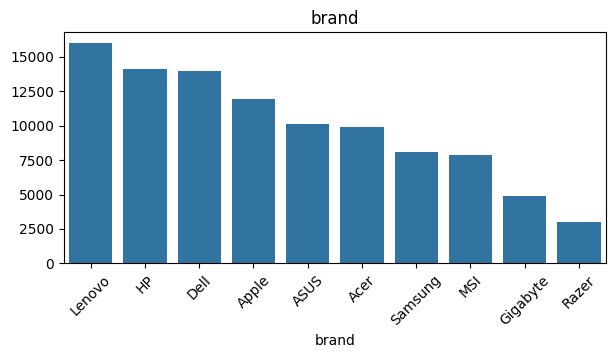

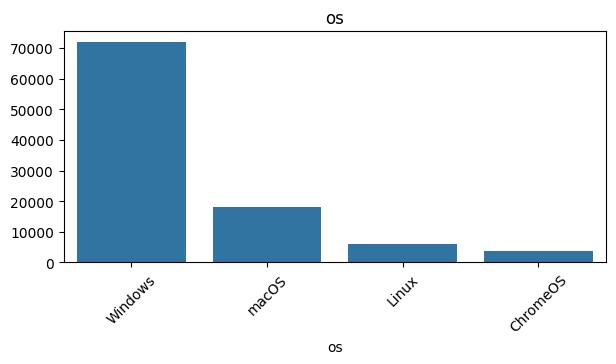

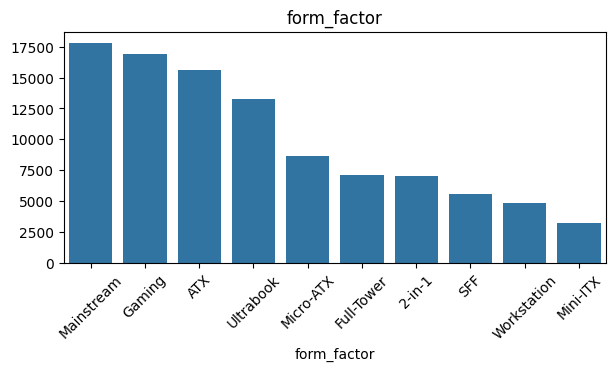

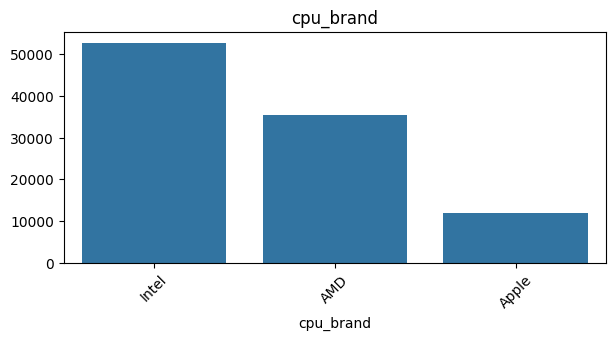

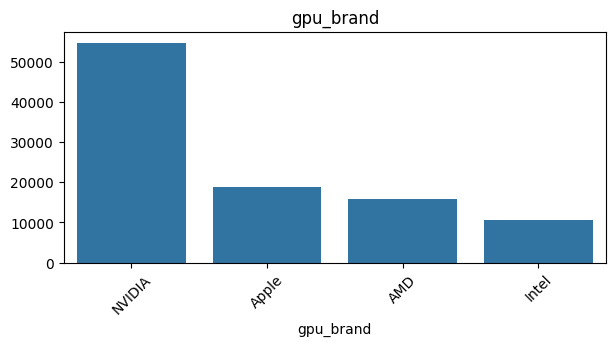

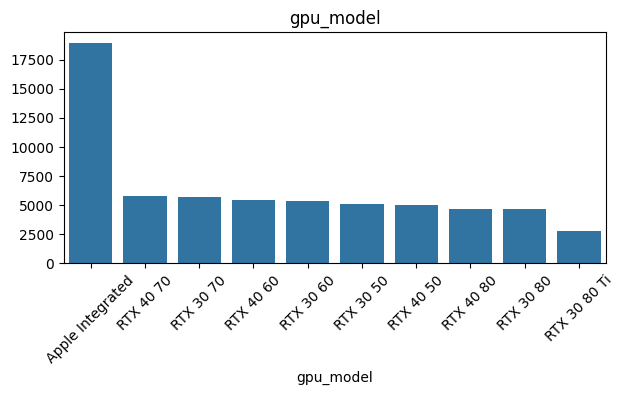

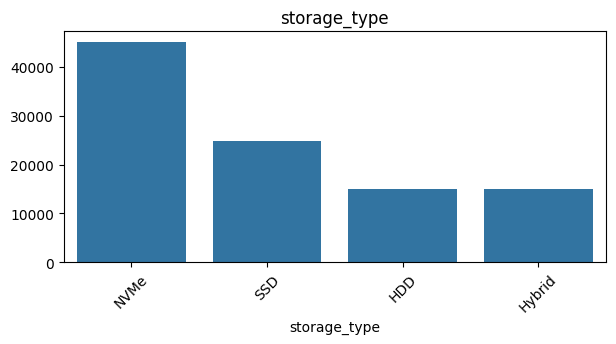

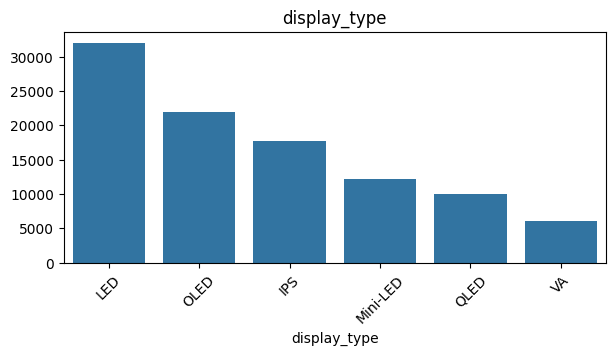

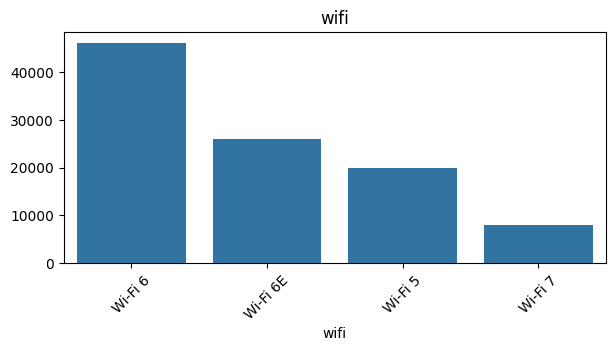

In [13]:
for col in num_cols:
    plt.figure(figsize=(6, 3))
    sns.histplot(compu_df[col], bins=30)
    plt.title(col)
    plt.show()

for col in cat_cols:
    conteo = compu_df[col].value_counts().head(10)
    plt.figure(figsize=(7, 3))
    sns.barplot(x=conteo.index.astype(str), y=conteo.values)
    plt.title(col)
    plt.xticks(rotation=45)
    plt.show()


No hay duplicados ni valores faltantes. En las numericas hay variables de capacidad como storage, vram y watts. En las categoricas, gpu_model es la que queda con mas categorias, por eso despues se codifica diferente.


3. Dibuja un mapa de calor con la matriz de correlación para las variables numéricas del conjunto de datos.
* Identifica los pares de variables cuya correlación sea superior a 0.9 e imprímelos.
* Reflexiona sobre cuáles variables, de las que se imprimieron, representan de manera general la capacidad del hardware y mantenlas; elimina las demás por aportar información redundante.
* Incluye una breve justificación de tus decisiones.

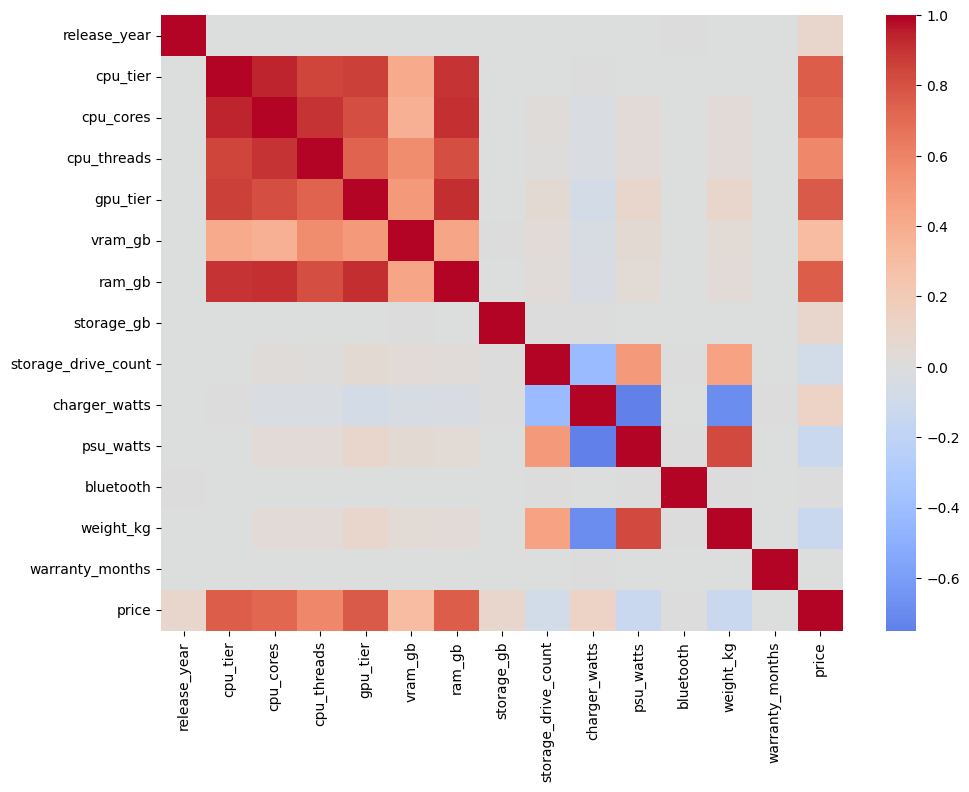

In [14]:
corr = compu_df[num_cols].corr()
plt.figure(figsize=(11, 8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.show()


In [15]:
pares_altos = []
for i, col1 in enumerate(num_cols):
    for col2 in num_cols[i+1:]:
        valor = corr.loc[col1, col2]
        if abs(valor) > 0.9:
            pares_altos.append([col1, col2, valor])

pares_altos_df = pd.DataFrame(pares_altos, columns=['variable_1', 'variable_2', 'correlacion'])
pares_altos_df


,variable_1,variable_2,correlacion
0,cpu_tier,cpu_cores,0.937376
1,cpu_cores,ram_gb,0.906770
2,gpu_tier,ram_gb,0.912918


In [16]:
compu_df = compu_df.drop(columns=['cpu_cores', 'ram_gb'])
num_cols = compu_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
compu_df.head()


,device_type,brand,release_year,os,form_factor,cpu_brand,cpu_tier,cpu_threads,gpu_brand,gpu_model,...,storage_gb,storage_drive_count,display_type,charger_watts,psu_watts,wifi,bluetooth,weight_kg,warranty_months,price
0,Desktop,Samsung,2022,Windows,ATX,Intel,3,24,NVIDIA,RTX 40 60,...,1024,1,LED,0,750,Wi-Fi 6,5.1,11.00,36,1383.99
1,Laptop,Samsung,2022,Windows,Mainstream,Intel,4,24,NVIDIA,RTX 40 80,...,512,1,OLED,120,0,Wi-Fi 6,5.3,2.03,12,2274.99
2,Desktop,Lenovo,2024,macOS,SFF,AMD,2,16,NVIDIA,RTX 40 50,...,512,2,LED,0,850,Wi-Fi 6,5.0,7.00,24,1879.99
3,Desktop,Dell,2024,Windows,ATX,AMD,2,12,AMD,RX 7000 60,...,512,2,IPS,0,650,Wi-Fi 6,5.2,6.00,36,1331.99
4,Laptop,Gigabyte,2024,Linux,Gaming,AMD,5,32,NVIDIA,RTX 30 80 Ti,...,256,1,Mini-LED,90,0,Wi-Fi 6,5.2,1.50,12,2681.99


Las correlaciones altas salen entre cpu_tier, cpu_cores, gpu_tier y ram_gb. Deje cpu_tier y gpu_tier porque resumen mejor la capacidad general del hardware. Quite cpu_cores y ram_gb para no repetir informacion muy parecida.


4. Para comenzar con la ingeniería de características, crea una copia del dataframe y asígnala a un nuevo objeto llamado `compu_transf`.
* Calcula cuántos años han pasado desde el lanzamiento de cada computadora y almacénalo en una nueva columna llamada `years_since_release`; luego, elimina la columna original.
* Utiliza `KBinsDiscretizer` para reemplazar la columna `vram_gb` en 4 bins ordinales basados en cuantiles.
* Imprime los valores que delimitan cada bin y haz un gráfico de barras para ver la cantidad de observaciones en cada uno, con el fin de entender cómo se agruparon los datos.

[ 0.  4.  6.  8. 16.]


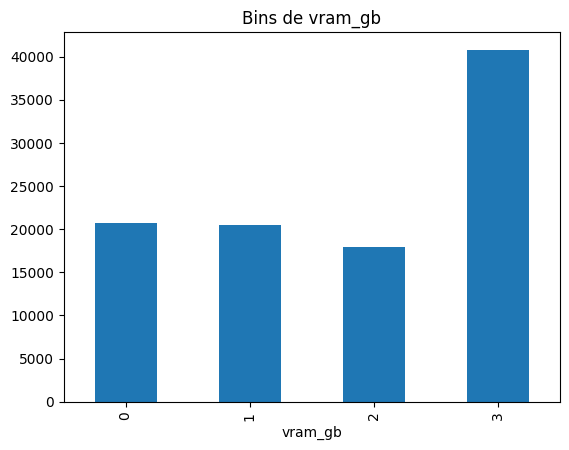

In [17]:
compu_transf = compu_df.copy()
compu_transf['years_since_release'] = date.today().year - compu_transf['release_year']
compu_transf = compu_transf.drop(columns='release_year')

kbins = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='quantile')
compu_transf['vram_gb'] = kbins.fit_transform(compu_transf[['vram_gb']]).astype(int)

print(kbins.bin_edges_[0])
compu_transf['vram_gb'].value_counts().sort_index().plot(kind='bar')
plt.title('Bins de vram_gb')
plt.show()


Cree years_since_release para usar la antiguedad en vez del año directo. vram_gb queda en 4 grupos por cuantiles, entonces los grupos quedan mas balanceados.


5. Observa los histogramas del ejercicio 2. Notarás que en las variables `charger_watts` y `psu_watts` aparece una barra en 0. Analiza por qué ocurre esto y qué significa en relación con el tipo de dispositivo.
* Como estas variables son mutuamente excluyentes, combínalas en una nueva columna llamada `power_watts` que contenga la potencia correspondiente de cada dispositivo y, a continuación, haz un histograma para verificar que la distribución resultante es bimodal.
* Por último, borra las columnas originales `charger_watts` y `psu_watts`.

In [18]:
pd.crosstab(compu_transf['device_type'], compu_transf['charger_watts'].eq(0))


charger_watts,False,True
device_type,,
Desktop,0,40156
Laptop,59844,0


In [19]:
pd.crosstab(compu_transf['device_type'], compu_transf['psu_watts'].eq(0))


psu_watts,False,True
device_type,,
Desktop,40156,0
Laptop,0,59844


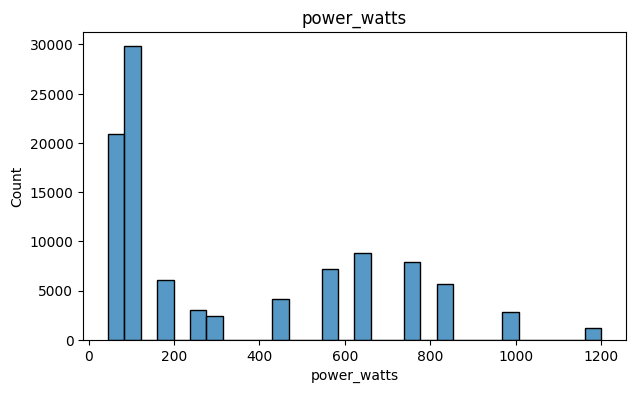

In [20]:
compu_transf['power_watts'] = compu_transf['charger_watts'] + compu_transf['psu_watts']

plt.figure(figsize=(7, 4))
sns.histplot(compu_transf['power_watts'], bins=30)
plt.title('power_watts')
plt.show()

compu_transf = compu_transf.drop(columns=['charger_watts', 'psu_watts'])


Los ceros aparecen porque las laptops tienen charger_watts pero no psu_watts, y las desktops tienen psu_watts pero no charger_watts. Por eso las dos columnas se pueden juntar en power_watts. El histograma queda con dos grupos, uno de laptops y otro de desktops.


6. Para disminuir el sesgo de la variable `price`, crea tres transformadores: logaritmo, raíz cuadrada y Box - Cox.
* Aplica cada transformador a la variable price, dejando el resultado en variables temporales. El objetivo es comparar los efectos de cada transformación antes de decidir cuál aplicar de manera definitiva sobre las variables continuas del dataframe.
* De la variable original y de cada una de las tres transformaciones se debe mostrar:
  * Histograma: para observar la distribución de los datos.
  * Boxplot: para identificar posibles valores atípicos.
  * Q-Q plot: para evaluar la normalidad de la variable.
  * Skew (sesgo): para cuantificar la asimetría de la distribución.
  * Cantidad de outliers: para conocer cuántos valores extremos existen.
* En función de los resultados obtenidos al comparar las transformaciones, decide cuál logró el mejor efecto sobre la distribución de la variable y aplícala directamente en el dataframe, reemplazando las variables continuas: `weight_kg`, `power_watts` y `price`.

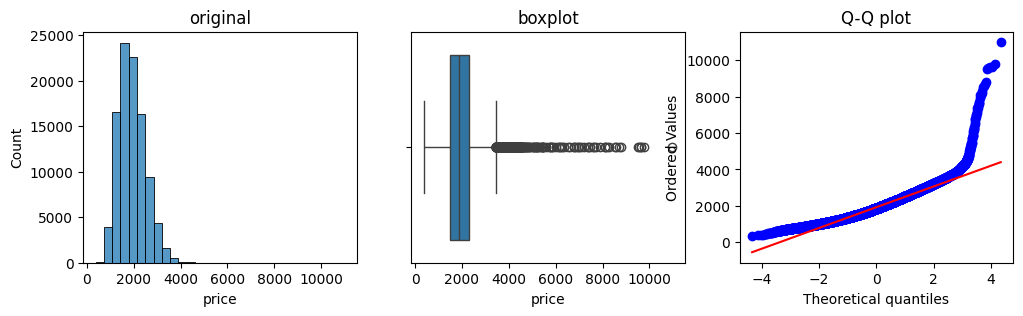

original
skew: 0.9866439454826036
outliers: 976



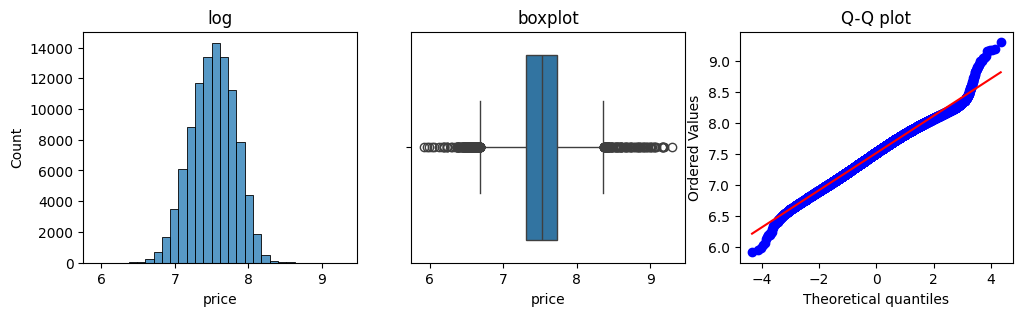

log
skew: -0.13310504376273052
outliers: 386



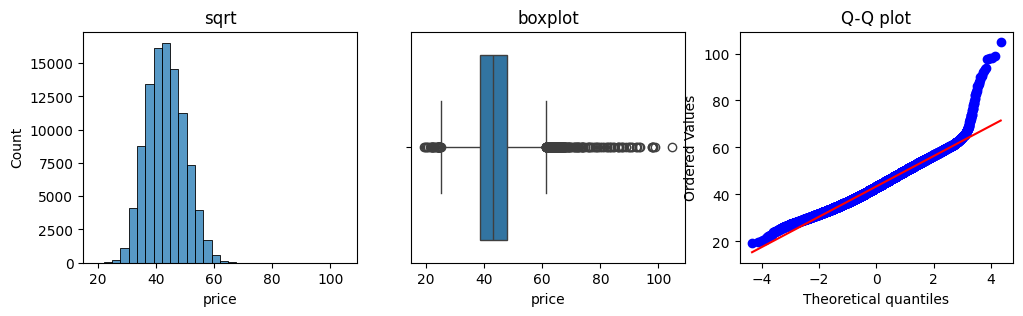

sqrt
skew: 0.33225281349895036
outliers: 364



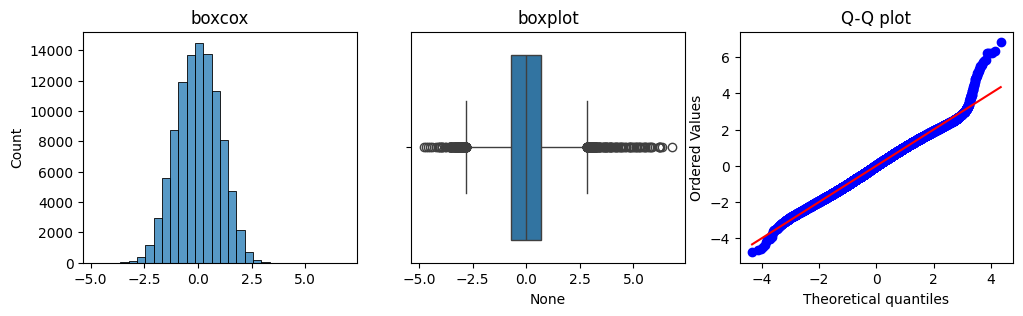

boxcox
skew: -0.00023827421419291098
outliers: 317



In [21]:
log_transformer = FunctionTransformer(np.log, validate=False)
sqrt_transformer = FunctionTransformer(np.sqrt, validate=False)
boxcox_transformer = PowerTransformer(method='box-cox')

price_original = compu_transf['price']
price_log = pd.Series(log_transformer.transform(price_original), index=compu_transf.index)
price_sqrt = pd.Series(sqrt_transformer.transform(price_original), index=compu_transf.index)
price_boxcox = pd.Series(boxcox_transformer.fit_transform(compu_transf[['price']]).ravel(), index=compu_transf.index)

price_comparacion = {
    'original': price_original,
    'log': price_log,
    'sqrt': price_sqrt,
    'boxcox': price_boxcox
}

for nombre, datos in price_comparacion.items():
    q1 = datos.quantile(0.25)
    q3 = datos.quantile(0.75)
    iqr = q3 - q1
    outliers = ((datos < q1 - 1.5 * iqr) | (datos > q3 + 1.5 * iqr)).sum()

    plt.figure(figsize=(12, 3))
    plt.subplot(1, 3, 1)
    sns.histplot(datos, bins=30)
    plt.title(nombre)

    plt.subplot(1, 3, 2)
    sns.boxplot(x=datos)
    plt.title('boxplot')

    plt.subplot(1, 3, 3)
    probplot(datos, dist='norm', plot=plt)
    plt.title('Q-Q plot')
    plt.show()

    print(nombre)
    print('skew:', datos.skew())
    print('outliers:', outliers)
    print()


In [22]:
continuas_transformar = ['weight_kg', 'power_watts', 'price']
boxcox_final = PowerTransformer(method='box-cox')
compu_transf[continuas_transformar] = boxcox_final.fit_transform(compu_transf[continuas_transformar])
compu_transf[continuas_transformar].describe()


,weight_kg,power_watts,price
count,1.000000e+05,1.000000e+05,1.000000e+05
mean,6.458833e-17,-2.769838e-15,3.464606e-15
std,1.000005e+00,1.000005e+00,1.000005e+00
min,-1.758728e+00,-1.591007e+00,-4.773885e+00
25%,-8.048445e-01,-7.678526e-01,-6.958078e-01
50%,-3.397152e-01,-4.529157e-01,1.130999e-02
75%,1.079395e+00,1.123151e+00,7.082988e-01
max,1.642859e+00,1.594800e+00,6.818838e+00


La transformacion Box-Cox fue la que dejo price con menos sesgo y menos outliers. Por eso aplique Box-Cox a price y tambien a weight_kg y power_watts, que son continuas y positivas.


7. Para que todas las variables numéricas estén en la misma escala, aplica `MinMaxScaler` de sklearn a todas las columnas numéricas del dataframe, reemplazando las columnas originales.

In [23]:
num_cols = compu_transf.select_dtypes(include=['int64', 'float64']).columns.tolist()
scaler = MinMaxScaler()
compu_transf[num_cols] = scaler.fit_transform(compu_transf[num_cols])
compu_transf[num_cols].describe()


,cpu_tier,cpu_threads,gpu_tier,vram_gb,storage_gb,storage_drive_count,bluetooth,weight_kg,warranty_months,price,years_since_release,power_watts
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.430698,0.295629,0.398270,0.595883,0.168733,0.174993,0.804331,0.517032,0.283343,0.411800,0.382736,0.499405
std,0.274635,0.186893,0.291929,0.394170,0.201626,0.265761,0.223616,0.293982,0.284219,0.086261,0.289394,0.313894
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.200000,0.153846,0.200000,0.333333,0.066667,0.000000,0.727273,0.280423,0.000000,0.351779,0.142857,0.258382
50%,0.400000,0.230769,0.400000,0.666667,0.066667,0.000000,0.818182,0.417162,0.333333,0.412776,0.285714,0.357238
75%,0.600000,0.384615,0.600000,1.000000,0.200000,0.333333,0.909091,0.834353,0.333333,0.472899,0.571429,0.851953
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Todas las numericas quedan escaladas de 0 a 1 para que ninguna pese mas solo por tener unidades mas grandes.


8. Aunque `wifi` es una variable categórica, sus categorías tienen un orden natural (Wi-Fi 5 < Wi-Fi 6 < Wi-Fi 6E < Wi-Fi 7). Codifícala usando `OrdinalEncoder`.
* Luego, escala la variable codificada entre 0 y 1 con `MinMaxScaler`, para que quede en la misma escala que las variables numéricas del dataframe.

Nota: Ambos cambios deben efectuarse sobre la columna original, de manera que quede una única columna `wifi` con toda la información transformada.

In [24]:
wifi_orden = [['Wi-Fi 5', 'Wi-Fi 6', 'Wi-Fi 6E', 'Wi-Fi 7']]
wifi_encoder = OrdinalEncoder(categories=wifi_orden)
compu_transf['wifi'] = wifi_encoder.fit_transform(compu_transf[['wifi']])

wifi_scaler = MinMaxScaler()
compu_transf[['wifi']] = wifi_scaler.fit_transform(compu_transf[['wifi']])
compu_transf[['wifi']].describe()


,wifi
count,100000.000000
mean,0.406670
std,0.284834
min,0.000000
25%,0.333333
50%,0.333333
75%,0.666667
max,1.000000


wifi tiene orden natural, por eso use OrdinalEncoder. Luego lo escale de 0 a 1 para que quede igual que las numericas.


9. La variable `gpu_model` tiene muchas categorías. Usar *One-Hot Encoding* aumentaría significativamente la dimensionalidad del dataframe. Por ello, utiliza `BinaryEncoder` para codificarla.
* Guarda el resultado en un dataframe llamado `bin_df`. Más adelante, lo combinarás con `compu_transf` para integrar las variables codificadas.

In [25]:
bin_encoder = BinaryEncoder(cols=['gpu_model'])
bin_df = bin_encoder.fit_transform(compu_transf[['gpu_model']])
bin_df.head()


,gpu_model_0,gpu_model_1,gpu_model_2,gpu_model_3,gpu_model_4,gpu_model_5
0,0,0,0,0,0,1
1,0,0,0,0,1,0
2,0,0,0,0,1,1
3,0,0,0,1,0,0
4,0,0,0,1,0,1


gpu_model tiene muchas categorias. Con BinaryEncoder se evita crear demasiadas columnas como pasaria con One-Hot.


10. Usa `OneHotEncoder` para codificar las variables categóricas restantes. Asegúrate de usar `drop='first'` para evitar la multicolinealidad y guarda el resultado en un dataframe llamado `ohe_df`
* Combina el dataframe `compu_transf` con las variables categóricas que fueron codificadas en `bin_df` y `ohe_df`. No olvides eliminar las variables originales.
* Usa `describe()` sobre el dataframe resultante para corroborar que todas las columnas estén escaladas entre 0 y 1 y que no queden variables categóricas sin codificar.

In [26]:
cat_cols = compu_transf.select_dtypes(include='object').columns.tolist()
cat_cols.remove('gpu_model')

ohe_encoder = OneHotEncoder(drop='first', sparse_output=False)
ohe_array = ohe_encoder.fit_transform(compu_transf[cat_cols])
ohe_df = pd.DataFrame(ohe_array, columns=ohe_encoder.get_feature_names_out(cat_cols), index=compu_transf.index)

gpu_cols = ['gpu_model']
compu_transf = compu_transf.drop(columns=cat_cols + gpu_cols)
compu_transf = pd.concat([compu_transf, bin_df, ohe_df], axis=1)

compu_transf.describe()


,cpu_tier,cpu_threads,gpu_tier,vram_gb,storage_gb,storage_drive_count,wifi,bluetooth,weight_kg,warranty_months,...,gpu_brand_Intel,gpu_brand_NVIDIA,storage_type_Hybrid,storage_type_NVMe,storage_type_SSD,display_type_LED,display_type_Mini-LED,display_type_OLED,display_type_QLED,display_type_VA
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.430698,0.295629,0.398270,0.595883,0.168733,0.174993,0.406670,0.804331,0.517032,0.283343,...,0.105990,0.547120,0.149810,0.450590,0.249370,0.320000,0.121880,0.219100,0.100690,0.060910
std,0.274635,0.186893,0.291929,0.394170,0.201626,0.265761,0.284834,0.223616,0.293982,0.284219,...,0.307826,0.497777,0.356887,0.497555,0.432651,0.466478,0.327149,0.413639,0.300919,0.239166
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.200000,0.153846,0.200000,0.333333,0.066667,0.000000,0.333333,0.727273,0.280423,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.400000,0.230769,0.400000,0.666667,0.066667,0.000000,0.333333,0.818182,0.417162,0.333333,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.600000,0.384615,0.600000,1.000000,0.200000,0.333333,0.666667,0.909091,0.834353,0.333333,...,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [27]:
compu_transf.select_dtypes(include='object').columns


Index([], dtype='object')

Las categoricas restantes se codificaron con One-Hot y drop first para no duplicar informacion. Al final ya no quedan columnas de texto y describe muestra que las variables estan entre 0 y 1.


---

**Declaración de uso de IA**

OpenAI. (2026). *Codex gpt 5.5 medium effort (modelo de lenguaje grande)*, utilizado como apoyo para revisión de errores.

---
